<a href="https://colab.research.google.com/github/pabloisai2199-ia/REDES-NEURONALES-ARTIFICIALES/blob/main/1_03_2_regla_de_aprendizajePABLO2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regla de aprendizaje de Rosenblatt

Pablo Isaí Núñez Isáis (A260696)

(4 puntos posibles)

El primer esfuerzo para que el perceptrón aprendiera a partir de datos fue la regla de aprendizaje presentada por Frank Rosenblatt. En este notebook aplicaremos dicha regla para observar el comportamiento sobre un conjuinto de datos sintético. Completa el código donde se te indica con "TODO".


In [8]:
# ==================== CONFIGURACIÓN INICIAL ====================

# MONTAMOS DRIVE PARA ACCEDER A LA CARPETA NNI
from google.colab import drive
import sys
import os

# 1. Montar Drive
print("Montando Google Drive...")
drive.mount('/content/drive')

# 2. Agregar la ruta de la carpeta nni al path de Python
nni_path = '/content/drive/MyDrive/REDES'
sys.path.insert(0, nni_path)

# 3. Verificar que todo está correcto
print(f"\nPath de Python actualizado con: {nni_path}")

try:
    import nni.functions as nf
    print(" nni.functions importado correctamente!")
    print(f"📦 Funciones disponibles en nni.functions:")
    # Mostrar algunas funciones útiles
    funciones_utiles = ['sigmoid', 'ReLU', 'datosSinteticos', 'step_function']
    for f in funciones_utiles:
        if hasattr(nf, f):
            print(f"  - {f}")
except ImportError as e:
    print(f"❌ Error al importar: {e}")
    print("\n Verificando estructura de carpetas...")

    # Verificar estructura
    base_path = '/content/drive/MyDrive/REDES'
    if os.path.exists(base_path):
        print(f" Carpeta REDES encontrada en: {base_path}")
        print(f"Contenido: {os.listdir(base_path)}")

        nni_folder = os.path.join(base_path, 'nni')
        if os.path.exists(nni_folder):
            print(f" Carpeta nni encontrada")
            print(f"Contenido: {os.listdir(nni_folder)}")
        else:
            print("❌ Carpeta nni NO encontrada en REDES")
    else:
        print("❌ Carpeta REDES NO encontrada en MyDrive")
        print("\nBuscando carpeta nni en todo MyDrive...")
        !find /content/drive/MyDrive -type d -name "nni" 2>/dev/null


Montando Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Path de Python actualizado con: /content/drive/MyDrive/REDES
 nni.functions importado correctamente!
📦 Funciones disponibles en nni.functions:
  - sigmoid
  - ReLU
  - datosSinteticos


In [9]:
import nni.functions as nf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import DecisionBoundaryDisplay
from matplotlib.colors import ListedColormap

colors = ['red', 'blue']

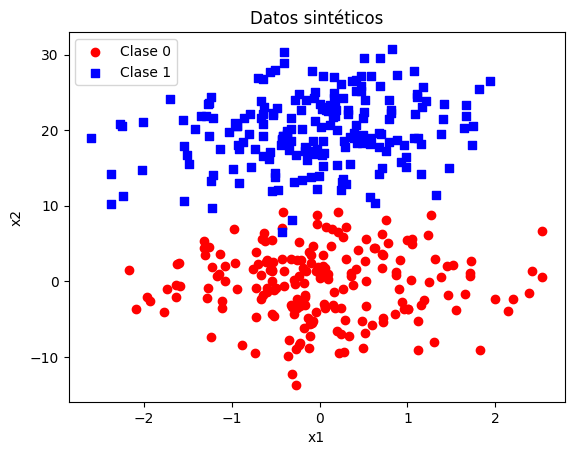

In [41]:
# Generar datos sintéticos
X, y = nf.datosSinteticos()

cmap = ListedColormap(colors[:len(np.unique(y))])

# Visualizar los datos
fig = plt.figure()
ax = fig.subplots()
ax.scatter(X.loc[y==0, 'x1'], X.loc[y==0, 'x2'], color='red', marker='o', label='Clase 0')
ax.scatter(X.loc[y==1, 'x1'], X.loc[y==1, 'x2'], color='blue', marker='s', label='Clase 1')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('Datos sintéticos')
ax.legend(loc='upper left')
plt.show()

## Perceptrón

A diferencia del ejercicio previo. En esta ocasión implementaremos el perceptrón como una clase.

In [42]:
class Perceptron:
    def __init__(self, n_entradas, f_activacion):
        self.n_entradas = n_entradas
        self.W = np.zeros((n_entradas,))
        self.b = 0.0
        self._f_activacion = f_activacion

    def inferencia(self, X):
        h = np.dot(X, self.W) + self.b
        return self._f_activacion(h)

def escalon(x):
    return np.where(x >= 0, 1, 0)

## Inicialización

El primer paso consite en inicializar los pesos.

Para inicializar los pesos con una distribución normal, podemos utilizar la función `numpy.random.normal`. Esta función permite especificar la media (`loc`), la desviación estándar (`scale`) y el número de valores a generar (`size`). Por ejemplo, `np.random.normal(loc=0, scale=1, size=(2,))` genera dos valores aleatorios con media 0 y desviación estándar 1. Esta inicialización es útil para romper la simetría y facilitar el aprendizaje del perceptrón.

In [43]:
# Crear una instancia del perceptrón
clasificador = Perceptron(n_entradas=2, f_activacion=escalon)
print("Pesos iniciales:", clasificador.W)
print("Bias inicial:", clasificador.b)

Pesos iniciales: [0. 0.]
Bias inicial: 0.0


In [58]:
# TODO: Inicialización de parámetros (1 punto)
clasificador.W = np.random.normal(loc=0, scale=1, size=(clasificador.n_entradas,))
clasificador.b = np.random.normal(loc=0, scale=1, size=(1,))
print("Pesos después de la inicialización:", clasificador.W)
print("Bias después de la inicialización:", clasificador.b)

Pesos después de la inicialización: [-1.07922772  1.72826104]
Bias después de la inicialización: [-0.84414167]


### Función de pérdida

La función de pérdida nos indica que tanto nos estamos equivocando en el conjunto de datos completo.

En este notebook usaremos la suma de los errores absolutos
$$
\mathcal{L} = SAE = \sum_\mu | y^\mu - \hat{y}^\mu
$$


In [59]:
# TODO: implementa la función de pérdida (1 punto)
def perdidaSAE(y_true, y_pred):
    # Suma de errores absolutos
    return np.sum(np.abs(y_true - y_pred))
    return None

y_pred = clasificador.inferencia(X)
print("Pérdida inicial (SAE):", perdidaSAE(y, y_pred))

Pérdida inicial (SAE): 91


A continuación visualizaremos el rendimiento del clasificador de forma gráfica

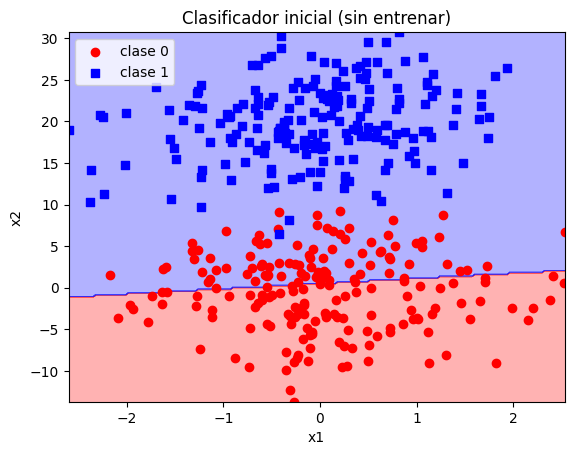

In [60]:
x1, x2 = np.meshgrid(
np.linspace(X.iloc[:,0].min(), X.iloc[:,0].max(), num=200),
    np.linspace(X.iloc[:,1].min(), X.iloc[:,1].max(), num=200)
)
grid = np.vstack([x1.ravel(), x2.ravel()]).T
y_pred = np.reshape(clasificador.inferencia(grid), x1.shape)

fig = plt.figure()
ax = fig.subplots()
display = DecisionBoundaryDisplay(xx0=x1, xx1=x2, response=y_pred)
display.plot(ax=ax, plot_method='contourf', cmap=cmap, alpha=0.3)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.scatter(X.loc[y==0, 'x1'], X.loc[y==0, 'x2'], color='red', marker='o', label='clase 0')
ax.scatter(X.loc[y==1, 'x1'], X.loc[y==1, 'x2'], color='blue', marker='s', label='clase 1')
ax.set_title('Clasificador inicial (sin entrenar)')
ax.legend(loc='upper left')
plt.show()

## Regla de aprendizaje

Primero, recordemos que la regla de aprendizase se basa en que cada error no guia hacia donde mover los pesos. Es decir usamos el error residual:

$$
e^\mu = y^\mu - \hat{y}^\mu
$$

Una vez definido el error residual observemos que la regla de aprendizaje se calcula como

$$
W^{t+1} = W^{t} + \eta (y - \hat{y}) X
$$

Y se repite el cálculo tantas veces como deseemos.


In [62]:
## Implementa la regla de aprendizaje (1 punto)
class ReglaDeAprendizaje:
    def __init__(self, tasa_aprendizaje=0.1):
        self.tasa_aprendizaje = tasa_aprendizaje

    def actualizar(self, perceptron, X, y):
        for xi, target in zip(X.values, y.values):
            output = perceptron.inferencia(xi)
            error = target - output
            perceptron.W = perceptron.W + self.tasa_aprendizaje * error * xi # Actualiza los pesos
            perceptron.b = perceptron.b + self.tasa_aprendizaje * error # Actualiza el sesgo

In [63]:
# Configuración del entrenamiento
tasa_aprendizaje = 0.1
n_epocas = 3

Época 1: Pérdida (SAE): 47
Época 2: Pérdida (SAE): 61
Época 3: Pérdida (SAE): 59


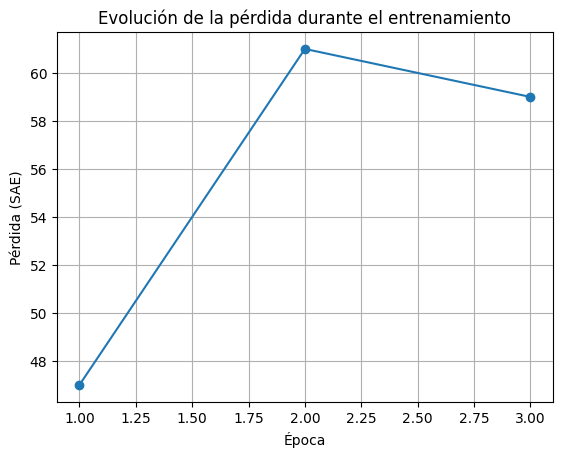

In [67]:
optimizador = ReglaDeAprendizaje(tasa_aprendizaje=tasa_aprendizaje)

historial_perdida = []

for epoca in range(n_epocas):
    y_pred = clasificador.inferencia(X)
    perdida = perdidaSAE(y, y_pred)
    print(f"Época {epoca+1}: Pérdida (SAE): {perdida}")
    historial_perdida.append(perdida)
    optimizador.actualizar(clasificador, X, y)

# Visualizar la pérdida a lo largo de las épocas
plt.plot(range(1, n_epocas + 1), historial_perdida, marker='o')
plt.xlabel('Época')
plt.ylabel('Pérdida (SAE)')
plt.title('Evolución de la pérdida durante el entrenamiento')
plt.grid()
plt.show()

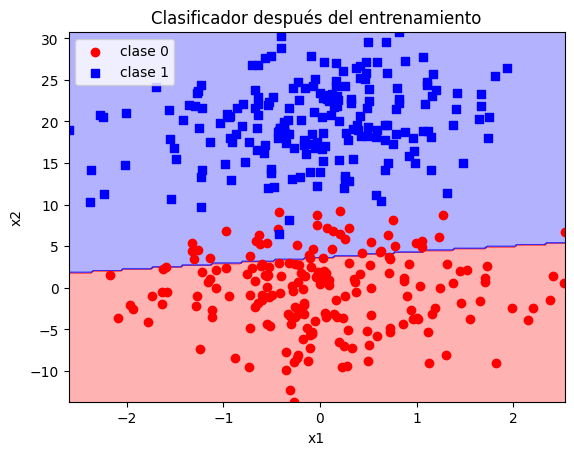

In [68]:
x1, x2 = np.meshgrid(
np.linspace(X.iloc[:,0].min(), X.iloc[:,0].max(), num=200),
    np.linspace(X.iloc[:,1].min(), X.iloc[:,1].max(), num=200)
)
grid = np.vstack([x1.ravel(), x2.ravel()]).T
y_pred = np.reshape(clasificador.inferencia(grid), x1.shape)

fig = plt.figure()
ax = fig.subplots()
display = DecisionBoundaryDisplay(xx0=x1, xx1=x2, response=y_pred)
display.plot(ax=ax, plot_method='contourf', cmap=cmap, alpha=0.3)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.scatter(X.loc[y==0, 'x1'], X.loc[y==0, 'x2'], color='red', marker='o', label='clase 0')
ax.scatter(X.loc[y==1, 'x1'], X.loc[y==1, 'x2'], color='blue', marker='s', label='clase 1')
ax.set_title('Clasificador después del entrenamiento')
ax.legend(loc='upper left')
plt.show()

Época 1: Pérdida (SAE): 288
Época 11: Pérdida (SAE): 39
Época 21: Pérdida (SAE): 50
Época 31: Pérdida (SAE): 41
Época 41: Pérdida (SAE): 24
Época 51: Pérdida (SAE): 35
Época 61: Pérdida (SAE): 24
Época 71: Pérdida (SAE): 12
Época 81: Pérdida (SAE): 21
Época 91: Pérdida (SAE): 12


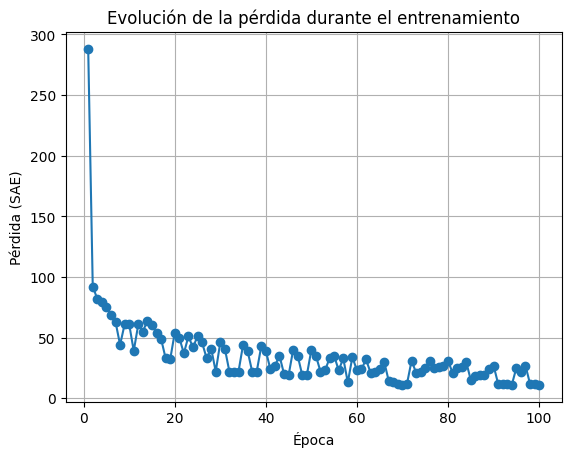


Pérdida final SAE: 12
Pesos finales: [-7.40766321  9.32208029]
Bias final: [-62.85027316]


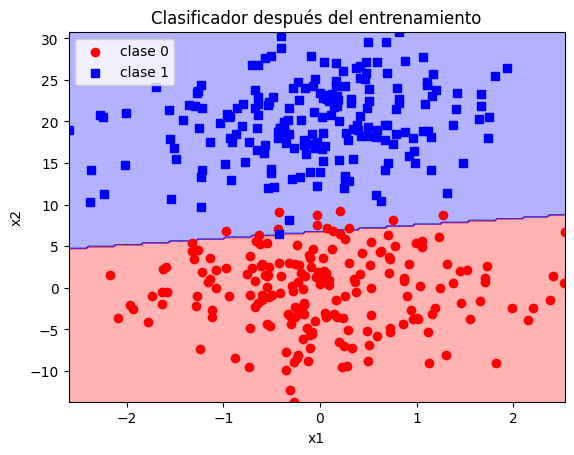

In [80]:
# TODO:2 puntos, modifica los hiperparámetros hasta que tengas una clasificación adecuada.
# No tiene que ser perfecto pero si se debe observar que los puntos rojos y azules en su mayoria esten correctamente clasificados.

clasificador = Perceptron(n_entradas=2, f_activacion=escalon)

clasificador.W = np.random.normal(loc=0, scale=0.5, size=(clasificador.n_entradas,))
clasificador.b = np.random.normal(loc=0, scale=0.5, size=(1,))

tasa_aprendizaje = 0.5
n_epocas = 100

optimizador = ReglaDeAprendizaje(tasa_aprendizaje=tasa_aprendizaje)

historial_perdida = []

for epoca in range(n_epocas):
    y_pred = clasificador.inferencia(X)
    perdida = perdidaSAE(y, y_pred)
    if epoca % 10 == 0:print(f"Época {epoca+1}: Pérdida (SAE): {perdida}")
    else:pass
    historial_perdida.append(perdida)
    optimizador.actualizar(clasificador, X, y)

# Visualizar la pérdida a lo largo de las épocas
plt.plot(range(1, n_epocas + 1), historial_perdida, marker='o')
plt.xlabel('Época')
plt.ylabel('Pérdida (SAE)')
plt.title('Evolución de la pérdida durante el entrenamiento')
plt.grid()
plt.show()

# Resultado final
y_pred_final = clasificador.inferencia(X)
perdida_final = perdidaSAE(y, y_pred_final)
print(f"\nPérdida final SAE: {perdida_final}")

# Mostrar pesos finales
print(f"Pesos finales: {clasificador.W}")
print(f"Bias final: {clasificador.b}")

#Visualizar el resultado del entrenamiento
x1, x2 = np.meshgrid(
np.linspace(X.iloc[:,0].min(), X.iloc[:,0].max(), num=200),
    np.linspace(X.iloc[:,1].min(), X.iloc[:,1].max(), num=200)
)
grid = np.vstack([x1.ravel(), x2.ravel()]).T
y_pred = np.reshape(clasificador.inferencia(grid), x1.shape)

fig = plt.figure()
ax = fig.subplots()
display = DecisionBoundaryDisplay(xx0=x1, xx1=x2, response=y_pred)
display.plot(ax=ax, plot_method='contourf', cmap=cmap, alpha=0.3)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.scatter(X.loc[y==0, 'x1'], X.loc[y==0, 'x2'], color='red', marker='o', label='clase 0')
ax.scatter(X.loc[y==1, 'x1'], X.loc[y==1, 'x2'], color='blue', marker='s', label='clase 1')
ax.set_title('Clasificador después del entrenamiento')
ax.legend(loc='upper left')
plt.show()

